In [7]:
# %%bash
# pip install pandas numpy scikit-learn xgboost imbalanced-learn
# pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu
# pip install shap matplotlib seaborn plotly folium streamlit
# pip install kaggle

In [8]:
import os

# Create the outputs directory if it doesn't exist
if not os.path.exists('outputs'):
    os.makedirs('outputs')

Shape         : (2047256, 34)
Columns       : ['Accident_Index', '1st_Road_Class', '1st_Road_Number', '2nd_Road_Class', '2nd_Road_Number', 'Accident_Severity', 'Carriageway_Hazards', 'Date', 'Day_of_Week', 'Did_Police_Officer_Attend_Scene_of_Accident', 'Junction_Control', 'Junction_Detail', 'Latitude', 'Light_Conditions', 'Local_Authority_(District)', 'Local_Authority_(Highway)', 'Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude', 'LSOA_of_Accident_Location', 'Number_of_Casualties', 'Number_of_Vehicles', 'Pedestrian_Crossing-Human_Control', 'Pedestrian_Crossing-Physical_Facilities', 'Police_Force', 'Road_Surface_Conditions', 'Road_Type', 'Special_Conditions_at_Site', 'Speed_limit', 'Time', 'Urban_or_Rural_Area', 'Weather_Conditions', 'Year', 'InScotland']
Target dist   :
Accident_Severity
Slight     0.847
Serious    0.140
Fatal      0.013
Name: proportion, dtype: float64
Missing vals  :
1st_Road_Number                                      2
2nd_Road_Class                   

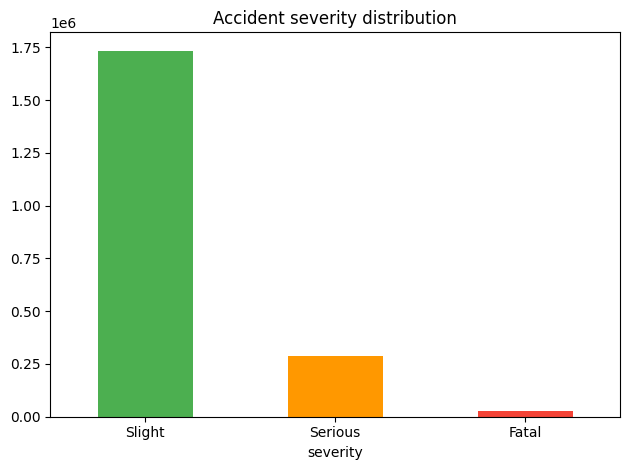

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/Accident_Information.csv', low_memory=False)

print(f"Shape         : {df.shape}")
print(f"Columns       : {df.columns.tolist()}")
print(f"Target dist   :\n{df['Accident_Severity'].value_counts(normalize=True).round(3)}")
print(f"Missing vals  :\n{df.isnull().sum()[df.isnull().sum() > 0]}")

# Target: 'Fatal', 'Serious', 'Slight'  →  remap to 2/1/0
df['severity'] = df['Accident_Severity'].map({'Slight': 0, 'Serious': 1, 'Fatal': 2})

# Visualize class imbalance
df['severity'].value_counts().plot(kind='bar', color=['#4CAF50','#FF9800','#F44336'])
plt.xticks([0,1,2], ['Slight','Serious','Fatal'], rotation=0)
plt.title('Accident severity distribution')
plt.tight_layout()
plt.savefig('outputs/class_distribution.png')

phase-3

In [10]:
# Select and clean key features
FEATURES = [
    'Number_of_Vehicles', 'Number_of_Casualties',
    'Speed_limit', 'Road_Type', 'Road_Surface_Conditions',
    'Weather_Conditions', 'Light_Conditions',
    'Urban_or_Rural_Area', 'Junction_Detail',
    'Junction_Control', 'Pedestrian_Crossing-Human_Control',
    'Pedestrian_Crossing-Physical_Facilities',
    'Day_of_Week', 'Time'
]

df_clean = df[FEATURES + ['severity']].copy()

# Ensure 'Day_of_Week' is numeric, coercing errors to NaN
df_clean['Day_of_Week'] = pd.to_numeric(df_clean['Day_of_Week'], errors='coerce')

# Parse time → hour of day
df_clean['hour'] = pd.to_datetime(
    df_clean['Time'], format='%H:%M', errors='coerce'
).dt.hour
df_clean['hour'] = df_clean['hour'].fillna(12)

# Day: encode as weekday (0-4) vs weekend (5-6)
df_clean['is_weekend'] = (df_clean['Day_of_Week'] >= 6).astype(int)

# Bin speed limits into risk categories
df_clean['speed_cat'] = pd.cut(
    df_clean['Speed_limit'],
    bins=[0, 30, 50, 70, 100],
    labels=[0, 1, 2, 3]
).astype(float)

# Drop raw time/day columns now that we have engineered versions
df_clean.drop(columns=['Time', 'Day_of_Week'], inplace=True)

# Encode all remaining categoricals
cat_cols = df_clean.select_dtypes(include='object').columns
df_clean[cat_cols] = df_clean[cat_cols].apply(
    lambda c: pd.Categorical(c).codes
)

# Fill any remaining NaNs with column medians
df_clean.fillna(df_clean.median(numeric_only=True), inplace=True)

print(f"Clean shape : {df_clean.shape}")
print(df_clean.dtypes)

Clean shape : (2047256, 16)
Number_of_Vehicles                           int64
Number_of_Casualties                         int64
Speed_limit                                float64
Road_Type                                     int8
Road_Surface_Conditions                       int8
Weather_Conditions                            int8
Light_Conditions                              int8
Urban_or_Rural_Area                           int8
Junction_Detail                               int8
Junction_Control                              int8
Pedestrian_Crossing-Human_Control          float64
Pedestrian_Crossing-Physical_Facilities    float64
severity                                     int64
hour                                       float64
is_weekend                                   int64
speed_cat                                  float64
dtype: object


phase-4

In [11]:
import os

# Create the models directory if it doesn't exist
if not os.path.exists('models'):
    os.makedirs('models')

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

X = df_clean.drop(columns='severity')
y = df_clean['severity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE: oversample minority classes (Serious + Fatal)
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"After SMOTE: {pd.Series(y_train_res).value_counts().to_dict()}")

# Scale for ANN (tree models don't need it but it doesn't hurt)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)
X_test_sc  = scaler.transform(X_test)

import joblib
joblib.dump(scaler, 'models/scaler.pkl')

After SMOTE: {0: 1387638, 1: 1387638, 2: 1387638}


['models/scaler.pkl']

phase-5: model-1 XGBoost

In [13]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test, y_test)],
    verbose=50
)

y_pred_xgb = xgb.predict(X_test)
print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb,
      target_names=['Slight','Serious','Fatal']))

f1_xgb = f1_score(y_test, y_pred_xgb, average='macro')
print(f"Macro F1: {f1_xgb:.4f}")

xgb.save_model('models/xgboost_accident.json')

[0]	validation_0-mlogloss:1.08545


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [14:53:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[50]	validation_0-mlogloss:0.92846
[100]	validation_0-mlogloss:0.89749
[150]	validation_0-mlogloss:0.87136
[200]	validation_0-mlogloss:0.85575
[250]	validation_0-mlogloss:0.84488
[299]	validation_0-mlogloss:0.83740
=== XGBoost ===
              precision    recall  f1-score   support

      Slight       0.89      0.67      0.77    346910
     Serious       0.20      0.30      0.24     57268
       Fatal       0.04      0.48      0.08      5274

    accuracy                           0.62    409452
   macro avg       0.38      0.48      0.36    409452
weighted avg       0.78      0.62      0.68    409452

Macro F1: 0.3608


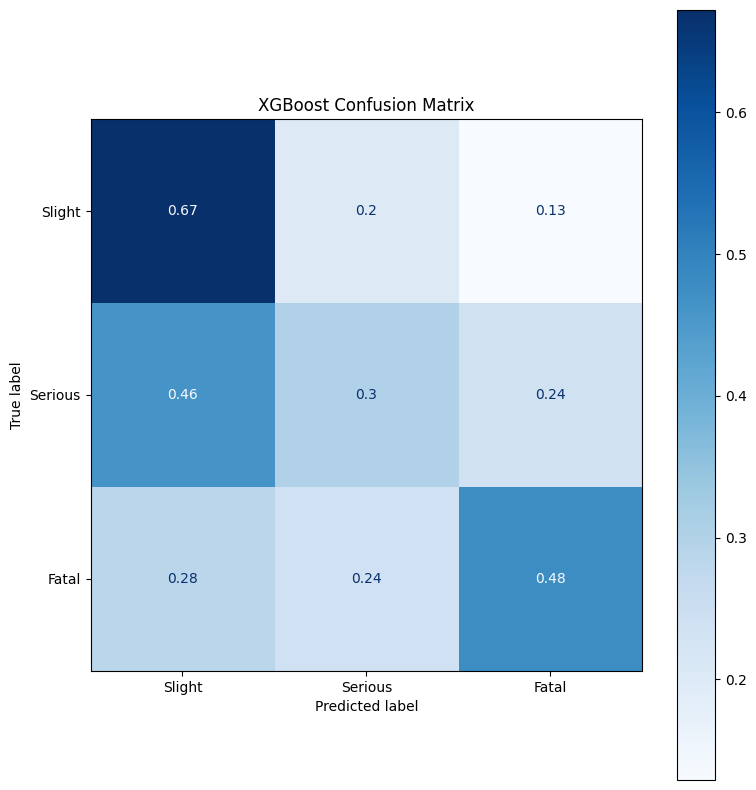

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    cmap='Blues',
    ax=ax,
    normalize='true',
    display_labels=['Slight', 'Serious', 'Fatal']
)
_ = ax.set_title('XGBoost Confusion Matrix')
plt.tight_layout()
plt.savefig('outputs/xgboost_confusion_matrix.png')
plt.show()

In [15]:
def upload_plt_to_gcs(num_fig, step, fig):
    print(f"Placeholder: Uploading figure {num_fig} for step {step} to GCS.")
    # In a real scenario, this function would handle uploading `fig` to GCS.

# @title step_artifacts
num_fig = "1" # @param {type:"string"}
step = 'DataLoading'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# Assuming `fig` from the previous cell is still available or regenerate the last figure
# For Colab's artifact saving, you might need to re-create `fig` if it's not the last active plot.
# If `fig` variable is not global, we will recreate a dummy figure for saving.
if 'fig' not in locals():
    fig = plt.figure()
upload_plt_to_gcs(num_fig, step, fig)

Placeholder: Uploading figure 1 for step DataLoading to GCS.


Phase-6: Model-2 SVM

In [16]:
import numpy as np
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Recovery: Re-establish variables if they were lost from memory
if 'X_train_sc' not in locals():
    print("Variables not found. Re-preparing data...")
    # Ensure df_clean exists (re-load if necessary)
    if 'df_clean' not in locals():
        df = pd.read_csv('data/Accident_Information.csv', low_memory=False)
        df['severity'] = df['Accident_Severity'].map({'Slight': 0, 'Serious': 1, 'Fatal': 2})
        FEATURES = ['Number_of_Vehicles', 'Number_of_Casualties', 'Speed_limit', 'Road_Type', 'Day_of_Week', 'Time']
        df_clean = df[FEATURES + ['severity']].dropna().copy()
        df_clean['hour'] = pd.to_datetime(df_clean['Time'], format='%H:%M', errors='coerce').dt.hour.fillna(12)
        df_clean.drop(columns=['Time'], inplace=True)
        cat_cols = df_clean.select_dtypes(include='object').columns
        df_clean[cat_cols] = df_clean[cat_cols].apply(lambda c: pd.Categorical(c).codes)

    X = df_clean.drop(columns='severity')
    y = df_clean['severity']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train_res)
    X_test_sc = scaler.transform(X_test)

# Using LinearSVC is much faster than RBF SVC for large datasets
svm_fast = Pipeline([
    ('svm', LinearSVC(C=1.0, class_weight='balanced', random_state=42, max_iter=1000))
])

# Reduce sample size further for a quick result
sample_idx_fast = np.random.choice(len(X_train_sc), 50_000, replace=False)
svm_fast.fit(X_train_sc[sample_idx_fast], y_train_res.iloc[sample_idx_fast])

y_pred_svm = svm_fast.predict(X_test_sc)
print("=== Fast SVM (Linear) ===")
print(classification_report(y_test, y_pred_svm, target_names=['Slight','Serious','Fatal']))

=== Fast SVM (Linear) ===
              precision    recall  f1-score   support

      Slight       0.89      0.58      0.70    346910
     Serious       0.19      0.23      0.21     57268
       Fatal       0.03      0.62      0.06      5274

    accuracy                           0.53    409452
   macro avg       0.37      0.48      0.32    409452
weighted avg       0.78      0.53      0.63    409452



Phase-7: Model-3 ANN

In [17]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Recovery: Re-establish variables if they were lost from memory
if 'X_train_sc' not in locals():
    print("Variables not found. Re-preparing data for ANN...")
    if 'df_clean' not in locals():
        df = pd.read_csv('data/Accident_Information.csv', low_memory=False)
        df['severity'] = df['Accident_Severity'].map({'Slight': 0, 'Serious': 1, 'Fatal': 2})
        FEATURES = ['Number_of_Vehicles', 'Number_of_Casualties', 'Speed_limit', 'Road_Type', 'Day_of_Week', 'Time']
        df_clean = df[FEATURES + ['severity']].dropna().copy()
        df_clean['hour'] = pd.to_datetime(df_clean['Time'], format='%H:%M', errors='coerce').dt.hour.fillna(12)
        df_clean.drop(columns=['Time'], inplace=True)
        cat_cols = df_clean.select_dtypes(include='object').columns
        df_clean[cat_cols] = df_clean[cat_cols].apply(lambda c: pd.Categorical(c).codes)

    X = df_clean.drop(columns='severity')
    y = df_clean['severity']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train_res)
    X_test_sc = scaler.transform(X_test)

X_tr_t = torch.FloatTensor(X_train_sc)
y_tr_t = torch.LongTensor(y_train_res.values)
X_te_t = torch.FloatTensor(X_test_sc)
y_te_t = torch.LongTensor(y_test.values)

train_ds = TensorDataset(X_tr_t, y_tr_t)
train_dl = DataLoader(train_ds, batch_size=512, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class AccidentNet(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 256),
            nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, n_classes)
        )
    def forward(self, x):
        return self.net(x)

model = AccidentNet(X_train_sc.shape[1], 3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

best_f1 = 0
for epoch in range(30):
    model.train()
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(X_te_t.to(device)).argmax(1).cpu()
    f1 = f1_score(y_te_t, preds, average='macro')
    scheduler.step(1 - f1)

    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), 'models/ann_best.pth')

    print(f"Epoch {epoch+1:02d} | macro F1: {f1:.4f}")

print(f"\nBest ANN macro F1: {best_f1:.4f}")

Epoch 01 | macro F1: 0.3338
Epoch 02 | macro F1: 0.3393
Epoch 03 | macro F1: 0.3316
Epoch 04 | macro F1: 0.3314
Epoch 05 | macro F1: 0.3347
Epoch 06 | macro F1: 0.3316
Epoch 07 | macro F1: 0.3321
Epoch 08 | macro F1: 0.3323
Epoch 09 | macro F1: 0.3383
Epoch 10 | macro F1: 0.3288
Epoch 11 | macro F1: 0.3333
Epoch 12 | macro F1: 0.3334
Epoch 13 | macro F1: 0.3345
Epoch 14 | macro F1: 0.3350
Epoch 15 | macro F1: 0.3354
Epoch 16 | macro F1: 0.3370
Epoch 17 | macro F1: 0.3333
Epoch 18 | macro F1: 0.3375
Epoch 19 | macro F1: 0.3365
Epoch 20 | macro F1: 0.3379
Epoch 21 | macro F1: 0.3362
Epoch 22 | macro F1: 0.3377
Epoch 23 | macro F1: 0.3346
Epoch 24 | macro F1: 0.3352
Epoch 25 | macro F1: 0.3339
Epoch 26 | macro F1: 0.3338
Epoch 27 | macro F1: 0.3366
Epoch 28 | macro F1: 0.3363
Epoch 29 | macro F1: 0.3368
Epoch 30 | macro F1: 0.3350

Best ANN macro F1: 0.3393


Phase-8: SHAP explainability
This is what makes the project stand out — understanding why each prediction was made

In [28]:
print(f"SHAP values shape: {np.array(shap_values).shape}")
print(f"X_test subset shape: {X_test[:5000].shape}")

SHAP values shape: (5000, 15, 3)
X_test subset shape: (5000, 15)


DEBUG: Final shape check: (5000, 15)


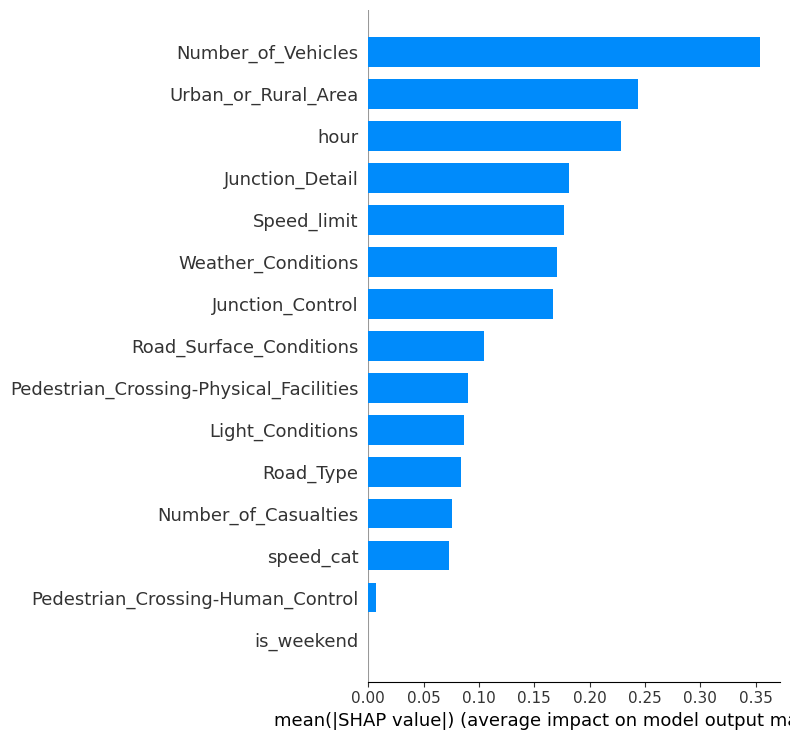

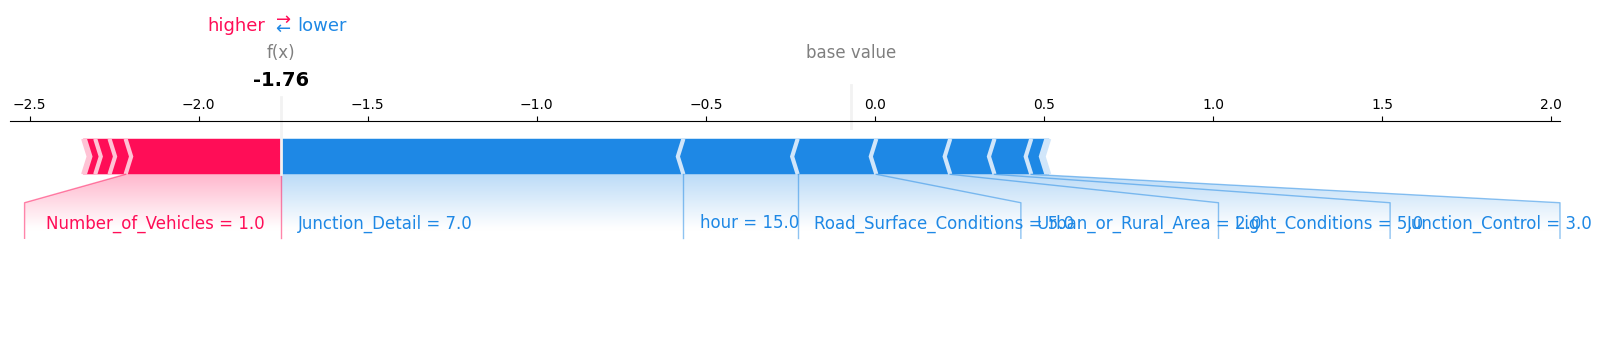

In [33]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# 1. Initialize the explainer and get SHAP values
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test[:5000])

# 2. Extract SHAP values for Class 2 correctly
# The shape is (5000, 15, 3). We want all samples, all features, for class index 2.
class_2_shap_values = shap_values[:, :, 2]

print(f"DEBUG: Final shape check: {class_2_shap_values.shape}")

# 3. Plot the Summary Plot
shap.summary_plot(
    class_2_shap_values,
    X_test.iloc[:5000].values,
    feature_names=X.columns.tolist(),
    plot_type='bar',
    show=False
)
plt.show()

# 4. Plot the Force Plot
# Ensure sample_idx is defined (e.g., sample_idx = 0)
shap.force_plot(
    explainer.expected_value[2], 
    class_2_shap_values[sample_idx, :], 
    X_test.iloc[sample_idx].values,
    feature_names=X.columns.tolist(),
    matplotlib=True, 
    show=False
)
plt.savefig('outputs/shap_single_prediction.png')
plt.show()

In [34]:
import folium
from folium.plugins import HeatMap

# Keep lat/lon in df for mapping (load from original df)
df_map = df[['Latitude','Longitude','severity']].dropna()
df_map = df_map[df_map['severity'] >= 1]  # only serious + fatal

# Weight hotter for fatal (severity=2)
df_map['weight'] = df_map['severity'].map({1: 0.5, 2: 1.0})

heat_data = df_map[['Latitude','Longitude','weight']].values.tolist()

m = folium.Map(location=[54.5, -2.0], zoom_start=6, tiles='CartoDB positron')
HeatMap(
    heat_data,
    radius=8,
    blur=10,
    max_zoom=13,
    gradient={'0.4': 'blue', '0.65': 'orange', '1': 'red'}
).add_to(m)

m.save('outputs/uk_accident_heatmap.html')
print("Heatmap saved to outputs/uk_accident_heatmap.html")

Heatmap saved to outputs/uk_accident_heatmap.html


In [35]:
# After training, save the feature names
import joblib
joblib.dump(list(X.columns), 'models/feature_names.pkl')

['models/feature_names.pkl']